# Analyze Statistics of Nash Equilibria

In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from tqdm import tqdm

In [38]:
df = pickle.load(open('data/equilibrium_stats/haar_8442b552/eqdata_randstates_haar_combined.pkl', 'rb'))
df_NE = df[df['nash_equilibrium'] == True]
df_NE = df_NE.assign(welfare=df_NE['energy'].apply(np.sum))
df_NE = df_NE.assign(tot_expl=df_NE['expl'].apply(np.sum))
df_NE.sort_values(by='welfare', ascending=False, inplace=True)
df_NE[['welfare', 'tot_expl']].head()

,welfare,tot_expl
311,6.924730,0.000894
2903,6.882104,0.000957
2738,6.856156,0.000881
5159,6.847764,0.000951
166,6.835258,0.000968


In [40]:
# For three qubits, the residual entropy is proportional to the hyperdeterminant

from src.solver import compute_ent_params_from_state
df_NE = df_NE.assign(ent_params=df_NE['state'].apply(compute_ent_params_from_state))
df_NE[['ent_params']].head()



,ent_params
311,"[0.5096628622578039, 0.5295882199174751, 0.508..."
2903,"[0.5073967718073169, 0.5058768571166086, 0.516..."
2738,"[0.5262223125069698, 0.5012427366902164, 0.503..."
5159,"[0.5050968811851346, 0.5046712691016535, 0.512..."
166,"[0.5201800734963884, 0.5223816182116948, 0.516..."


Text(0.5, 1.0, 'Welfare vs Hyperdeterminant')

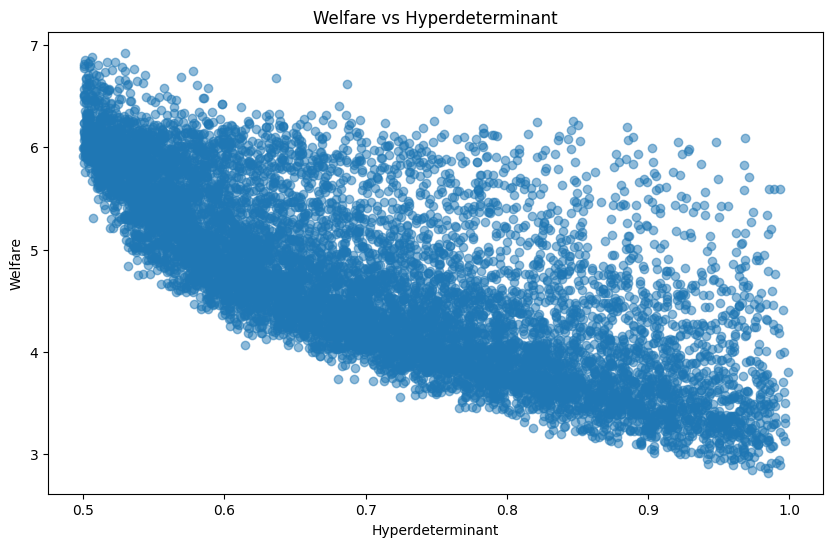

In [44]:
import matplotlib.pyplot as plt
X = df_NE['ent_params'].apply(lambda x: x[1]).to_numpy()
Y = df_NE['welfare'].to_numpy()
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.5)
plt.xlabel('Hyperdeterminant')
plt.ylabel('Welfare')
plt.title('Welfare vs Hyperdeterminant')

## New data for 6-player fixed bond dimension games

In [1]:
import pickle
df = pickle.load(open('data/equilibrium_stats/eqdata_randstates_chi3_combined.pkl', 'rb'))
df.head()

,nash_state,nash_equilibrium,energy,state,state_,num_iters,expl
0,False,True,"[1.046311797036932, 1.5141475610085886, 1.0899...",[[[[[[ 0.00533281 -0.01026661]\n [-0.00283194...,"[[[[0.12059959 0.99270123]], [[ 0.99270123 -0....",790,"[0.0, 9.044412374592525e-08, 0.000947747254325..."
1,False,True,"[1.2459651998924048, 1.6162940681204059, 1.178...",[[[[[[-0.00026578 -0.00181699]\n [ 0.0008028 ...,"[[[[-0.13153678 -0.99131129]], [[-0.99131129 ...",790,"[0.00032193704866023687, 0.0, 0.00053274164534..."


In [5]:
df_paths = ["data/equilibrium_stats/chi3/eqdata_randstates_combined_20260101_210406_c03ccbbf.pkl", "data/equilibrium_stats/chi4/eqdata_randstates_combined_20260101_210434_b5a43dc6.pkl", "data/equilibrium_stats/chi6/eqdata_randstates_combined_20260101_210453_81e0e43e.pkl", "data/equilibrium_stats/chi8/eqdata_randstates_combined_20260101_210513_aea6e264.pkl", "data/equilibrium_stats/haar/eqdata_randstates_combined_20260101_210601_2be97a22.pkl"]

dfs = []
for path in tqdm(df_paths):
    dfs.append(pickle.load(open(path, 'rb')))


100%|██████████| 5/5 [00:08<00:00,  1.76s/it]


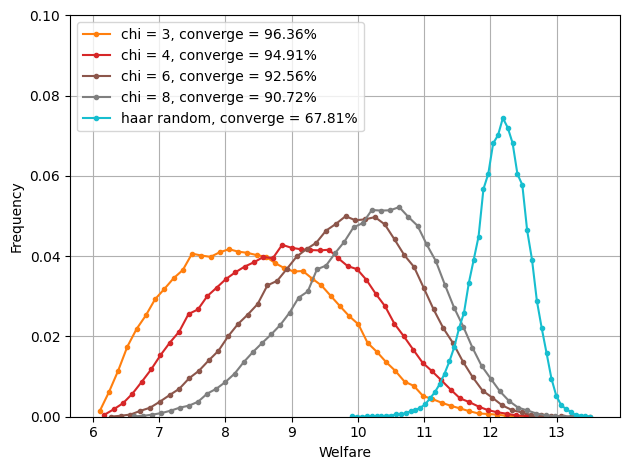

In [25]:
import matplotlib.pyplot as plt

bond_dims = [3, 4, 6, 8]
for i in range(len(dfs)):
    df = dfs[i]
    df = df.assign(tot_expl=df['expl'].apply(np.sum))
    df = df.assign(welfare=df['energy'].apply(np.sum))
    df_converged = df[df['nash_equilibrium'] == True]
    converge_percentage = df['nash_equilibrium'].value_counts() / len(df)

    plt_name = f'chi = {bond_dims[i]}, converge = {converge_percentage[True]:.2%}' if i <= 3 else f'haar random, converge = {converge_percentage[True]:.2%}'

    counts, bins, patches = plt.hist(df_converged['welfare'], bins=50, alpha=0, label=None)  # invisible, get values
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    freqs = counts / len(df_converged)
    plt.plot(bin_centers, freqs, marker='.', label=plt_name)


plt.xlabel('Welfare')
plt.ylabel('Frequency')
plt.grid(True)
# plt.title('Welfare Distribution of Converged Nash Equilibria with random initial states from different measures')
plt.ylim(0, 0.1)
plt.tight_layout()
plt.legend()
plt.show()

## Data for 3 player non-commutative payoffs

In [71]:
data_folder_0p8 = "data/equilibrium_stats_v1/noncomm_norm_0p8"
import pandas as pd

# Gather all DataFrames in a list
df_list = []
for filename in os.listdir(data_folder_0p8):
    if filename.endswith('.pkl'):
        df = pickle.load(open(os.path.join(data_folder_0p8, filename), 'rb'))
        df_list.append(df)

# Concatenate all DataFrames into a single DataFrame
df_NE_0p8 = pd.concat(df_list, ignore_index=True)
print(df_NE_0p8.head())

# compute welfare and state entanglement parameters
df_NE_0p8['ent_params'] = df_NE_0p8['state'].apply(compute_ent_params_from_state)
df_NE_0p8['welfare'] = df_NE_0p8['energy'].apply(np.sum)

data_folder_1p5 = "data/equilibrium_stats_v1/noncomm_norm_1p5"
df_list = []
for filename in os.listdir(data_folder_1p5):
    if filename.endswith('.pkl'):
        df = pickle.load(open(os.path.join(data_folder_1p5, filename), 'rb'))
        df_list.append(df)

df_NE_1p5 = pd.concat(df_list, ignore_index=True)
print(df_NE_1p5.head())

# compute welfare and state entanglement parameters
df_NE_1p5['ent_params'] = df_NE_1p5['state'].apply(compute_ent_params_from_state)
df_NE_1p5['welfare'] = df_NE_1p5['energy'].apply(np.sum)


   nash_state  nash_equilibrium  \
0       False              True   
1       False              True   
2       False              True   
3       False              True   
4        True             False   

                                              energy  \
0  [1.5812366824990143, 1.8008735499221797, 2.222...   
1  [1.5550077702655452, 2.061616119910299, 1.9154...   
2  [1.692262126200939, 2.346920617759528, 1.81113...   
3  [1.69650481480772, 2.06060423731513, 2.1661786...   
4  [1.412450869413038, 1.7224192319493628, 1.8446...   

                                               state  \
0  [[[(-0.14727891030326207+0.10815788723330237j)...   
1  [[[(-0.025201016056056565-0.030320510826256003...   
2  [[[(0.09606992372462526-0.05866220019149013j),...   
3  [[[(-0.04038035185960072+0.14680464754808972j)...   
4  [[[(-0.01196779372258551+0.05927345403237805j)...   

                                              state_  num_iters  \
0  [[[[-0.30174863-0.16107786j  0.93777651-0.059

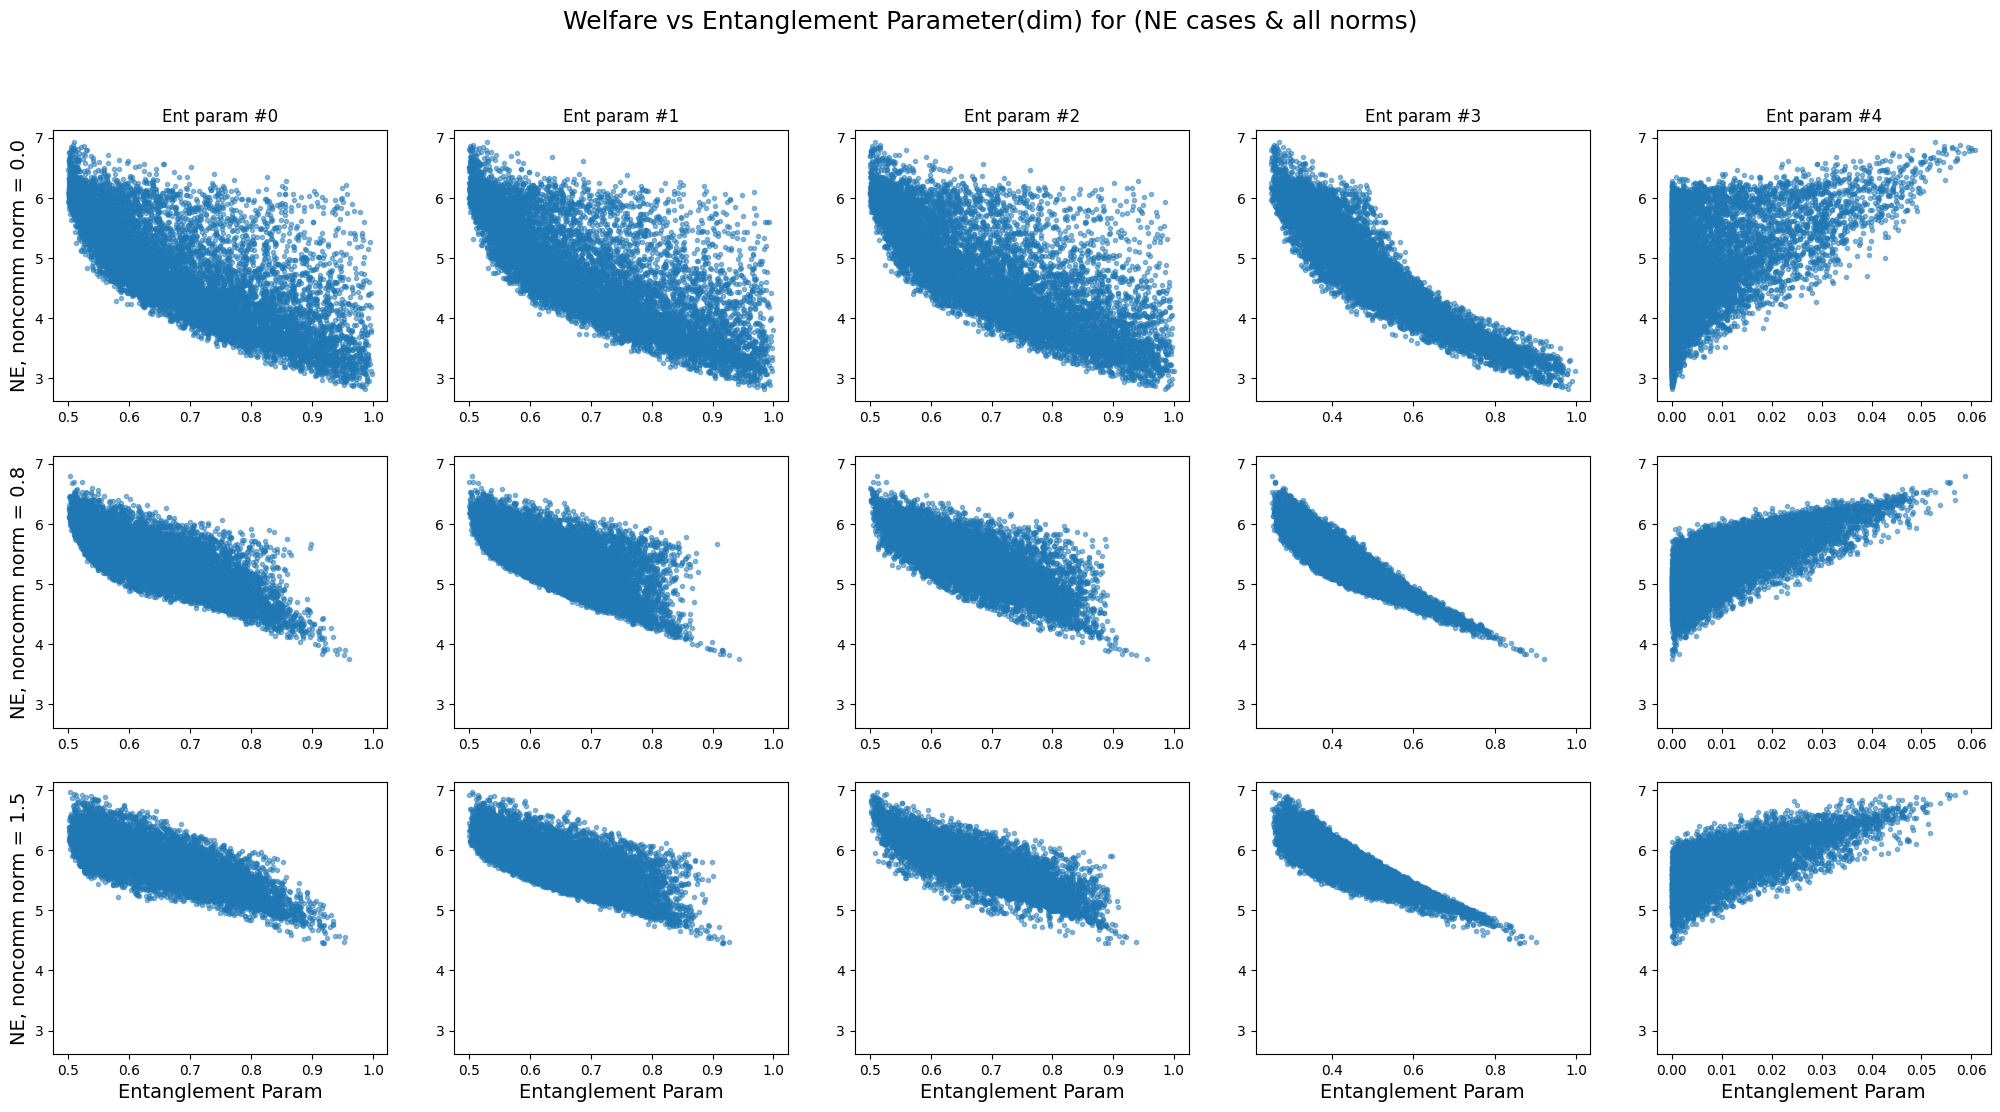

In [78]:
# Plot Welfare vs Entanglement Parameter with inds from 0 to 4, as a 3 row x 5 col grid

fig, axes = plt.subplots(3, 5, figsize=(25, 12), sharex=False, sharey=False)

# Each row: [NE, noncomm norm=0.0], [NE, noncomm norm=0.8], [NE, noncomm norm=1.5]
ent_cases = [
    ("NE, noncomm norm = 0.0", df_NE),
    ("NE, noncomm norm = 0.8", df_NE_0p8[df_NE_0p8['nash_equilibrium']]),
    ("NE, noncomm norm = 1.5", df_NE_1p5[df_NE_1p5['nash_equilibrium']])
]

# Compute xlim and ylim per column (i.e., per ent_param index) from row 0 (ent_cases[0][1])
col_xlims = []
col_ylims = []
for inds in range(5):
    x_col = np.real(ent_cases[0][1]['ent_params'].apply(lambda x: x[inds]).to_numpy())
    y_col = ent_cases[0][1]['welfare'].to_numpy()
    # Slightly increase the x and y range by 2.5% margin on each side
    x_margin = 0.05 * (np.max(x_col) - np.min(x_col))
    y_margin = 0.05 * (np.max(y_col) - np.min(y_col))
    xlim_col = (np.min(x_col) - x_margin, np.max(x_col) + x_margin)
    ylim_col = (np.min(y_col) - y_margin, np.max(y_col) + y_margin)
    col_xlims.append(xlim_col)
    col_ylims.append(ylim_col)

for row, (label, df) in enumerate(ent_cases):
    for inds in range(5):
        ax = axes[row, inds]
        x = np.real(df['ent_params'].apply(lambda x: x[inds]).to_numpy())
        y = df['welfare'].to_numpy()
        ax.scatter(x, y, marker='.', alpha=0.5)
        ax.set_xlim(col_xlims[inds])
        ax.set_ylim(col_ylims[inds])
        if row == 0:
            ax.set_title(f'Ent param #{inds}')
        if inds == 0:
            ax.set_ylabel(label, fontsize=14)
        if row == 2:
            ax.set_xlabel('Entanglement Param', fontsize=14)

plt.suptitle('Welfare vs Entanglement Parameter(dim) for (NE cases & all norms)', fontsize=18)
# plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()




## Non-commutative Hamiltonian

In [12]:
filepath = "data/qpd_3player_nocomm/qpd3_20260103_122051_06c94f4a.pkl"
df = pickle.load(open(filepath, 'rb'))
df = pd.DataFrame(df['metric_logs'])
df.tail()



,energy,welfare,state,ent_params
995,"[2.35454200684699, 2.407153223747098, 2.411018...",7.172714,[[[[-0.02200972+0.37370128j -0.2959647 -0.5128...,"[(0.500407838955734+0j), (0.5004641018768401+0..."
996,"[2.3622088868626943, 2.4033116218770685, 2.410...",7.176002,[[[[-0.02359597+0.38239243j -0.24668251-0.5319...,"[(0.5004193576369649+0j), (0.5003789496989933+..."
997,"[2.356604621215724, 2.39352751165256, 2.416333...",7.166466,[[[[-0.03276136+0.38180952j -0.25017577-0.5300...,"[(0.5004193576369633+0j), (0.5003494872242522+..."
998,"[2.3535772021897214, 2.4068416337609846, 2.415...",7.176128,[[[[-0.31675255+0.04353408j -0.30481503-0.5461...,"[(0.500360699957792+0j), (0.5004074207724621+0..."
999,"[2.3465070645450354, 2.4037030204773457, 2.422...",7.172564,[[[[-0.35606849-0.02579717j -0.29865355-0.5257...,"[(0.5003606999577916+0j), (0.5004150761984918+..."


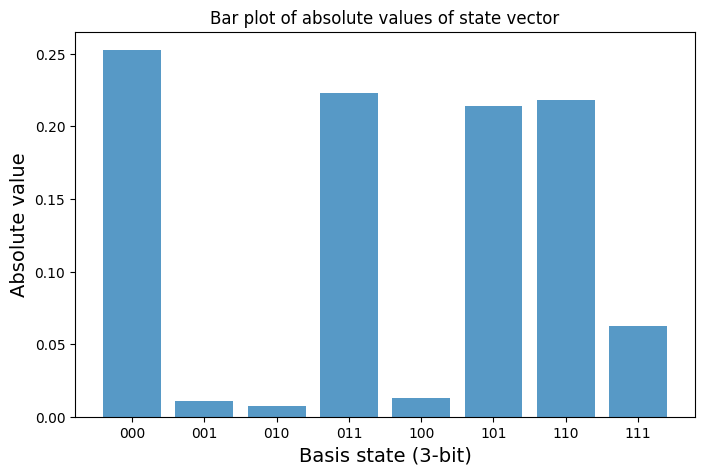

In [11]:
from src.mps_utils import to_comp_basis
df['state'].iloc[-1]
vec = to_comp_basis(df['state'].iloc[-1])
plt.figure(figsize=(8, 5))
abs_vec = np.abs(vec)**2
indices = np.arange(len(abs_vec))

# Generate 3-digit bitstrings as xtick labels
bitlabels = [f"{i:03b}" for i in indices]

plt.bar(indices, abs_vec, alpha=0.75)
plt.xlabel('Basis state (3-bit)', fontsize=14)
plt.ylabel('Absolute value', fontsize=14)
plt.title('Bar plot of absolute values of state vector')
plt.xticks(indices, bitlabels, rotation=0, fontsize=10)
plt.show()
